# Step 1: The Problem

For this project, we will look into how much does military service influences family income and wheter if it's worth joining the military to get a free ride in college and possibly making more money or if on the other hand, you would be better off by directly going to college and getting a degree taking into account how much an individual can pay to attend college. To finish, this will be a direct comparison between military service and college degree versus income. Moreover, I have chosen the data of a span of 20 years to see trends more or less have a bigger picture of how much inflattion plays a role in this (although I would like to compare the own/rent home with the median prices of homes right now). To finish, I will run a predictive model to see how accurate I can get with just these variables in predicting future incomes.


# STEP 2: Collect the Data

I downloaded the data from PSID with the variable format. **Reference to PSID here from website**

In [1]:
import pandas as pd
from openpyxl import load_workbook
import seaborn as sns # type: ignore
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np



# Load the Excel file & observe the first few rows
df = pd.read_excel("J354252_clean.xlsx", engine='openpyxl')
print(df.head())

# print the total count of non-null values in the 'ER82018' column
print(df['ER82018'].count())
print(df['ER82018'].isnull().sum())
print(df['ER82018'].min())



   ER17001  ER17002  ER17007  ER17013  ER17043  ER19993  ER19996  ER20013  \
0      7.0     96.0      1.0     49.0      1.0      5.0      5.0      0.0   
1      7.0   5987.0      0.0     47.0      1.0      5.0      5.0      0.0   
2      NaN      NaN      NaN      NaN      NaN      NaN      NaN      NaN   
3      7.0   7091.0      0.0     41.0      1.0      5.0      5.0      0.0   
4      7.0   5964.0      1.0     36.0      1.0      5.0      5.0      0.0   

   ER20423  ER20456  ...  ER82001  ER82002  ER82007  ER82018  ER82032  \
0      0.0  50880.0  ...      NaN      NaN      NaN      NaN      NaN   
1  25000.0  50000.0  ...      NaN      NaN      NaN      NaN      NaN   
2      NaN      NaN  ...      NaN      NaN      NaN      NaN      NaN   
3      0.0  55616.0  ...      1.0   3711.0      0.0     62.0      1.0   
4      0.0  33760.0  ...      NaN      NaN      NaN      NaN      NaN   

   ER85126  ER85129  ER85147  ER85478  ER85629  
0      NaN      NaN      NaN      NaN      NaN  


# STEP 3: Clean the Data

After inspecting the dataset, we can see that we have a lot of cleaning to do. Therefore we will focus on renaming the labels (columns) and split the data by year so we can access it easily and dropping any na values that we may have.

In [2]:
# Define variable labels mapping
var_labels = {
    "ER17001": "RELEASE NUMBER 2001",
    "ER17002": "2001 FAMILY INTERVIEW (ID) NUMBER",
    "ER17007": "FAMILY COMPOSITION CHANGE 2001",
    "ER17013": "AGE OF HEAD 2001",
    "ER17043": "OWN/RENT OR WHAT 2001",
    "ER19993": "ETHNIC GROUP 2001",
    "ER19996": 'MILITARY SERVICE 2001',
    "ER20013": "RCD COLLEGE DEGREE 2001",
    "ER20423": "HD ASSET INCOME FROM BUSINESS-2000",
    "ER20456": "TOTAL FAMILY INCOME-2000",
    "ER42001": "RELEASE NUMBER 2009",
    "ER42002": "2009 FAMILY INTERVIEW (ID) NUMBER",
    "ER42007": "FAMILY COMPOSITION CHANGE 2009",
    "ER42017": "AGE OF HEAD 2009",
    "ER42029": "OWN/RENT OR WHAT 2009",
    "ER46547": "ETHNIC GROUP 2009",
    "ER46550": 'MILITARY SERVICE 2009',
    "ER46567": "RCD COLLEGE DEGREE 2009",
    "ER46809": "HD ASSET INCOME FROM BUSINESS-2008",
    "ER46935": "TOTAL FAMILY INCOME-2008",
    "ER66001": "RELEASE NUMBER 2017",
    "ER66002": "2017 FAMILY INTERVIEW (ID) NUMBER",
    "ER66007": "FAMILY COMPOSITION CHANGE 2017",
    "ER66017": "AGE OF REFERENCE PERSON 2017",
    "ER66030": "OWN/RENT OR WHAT 2017",
    "ER70887": "ETHNIC GROUP 2017",
    "ER70890": "MILITARY SERVICE 2017",
    "ER70908": "RCD COLLEGE DEGREE 2017",
    "ER71275": "RP ASSET INCOME FROM BUSINESS-2016",
    "ER71426": "TOTAL FAMILY INCOME-2016",
    "ER82001": "RELEASE NUMBER 2023",
    "ER82002": "2023 FAMILY INTERVIEW (ID) NUMBER",
    "ER82007": "FAMILY COMPOSITION CHANGE 2023",
    "ER82018": "AGE OF REFERENCE PERSON 2023",
    "ER82032": "OWN/RENT OR WHAT 2023",
    "ER85126": "ETHNIC GROUP 2023",
    "ER85129": "MILITARY SERVICE 2023",
    "ER85147": "RCD COLLEGE DEGREE 2023",
    "ER85478": "RP ASSET INCOME FROM BUSINESS-2022",
    "ER85629": "TOTAL FAMILY INCOME-2022"
}


# Rename columns using the variable labels mapping
df.rename(columns=var_labels, inplace=True)

# Print column names and their positions
print("Column names and their positions:")
for i, col in enumerate(df.columns):
    print(f"Column {i}: {col}")

# Print column 33 (showing both position and name)
column_33_name = df.columns[33]
print(f"\nColumn 33 ({column_33_name}) values:")
print(df[column_33_name])

# print(df.head())
# print(df.columns)

# Split dataframe per year with no NA values
df_2001 = df.iloc[:, 0:10].copy()
df_2009 = df.iloc[:, 10:20].copy()
df_2017 = df.iloc[:, 20:30].copy()
df_2023 = df.iloc[:, 30:40].copy()

# Function to clean data consistently across all years
def clean_year_data(df_year, year):
 
    df_clean = df_year.copy()
    
    # Remove unknown military service (code 9)
    df_clean = df_clean[df_clean[f"MILITARY SERVICE {year}"] != 9]
    
    # Remove unknown own/rent values (codes 0, 9)
    df_clean = df_clean[~df_clean[f"OWN/RENT OR WHAT {year}"].isin([0, 9])]
    
    # Remove unknown ethnic groups (codes 6, 7, 9)
    df_clean = df_clean[~df_clean[f"ETHNIC GROUP {year}"].isin([6, 7, 9])]
    
    # Remove unknown college degree (codes 0, 9)
    df_clean = df_clean[~df_clean[f"RCD COLLEGE DEGREE {year}"].isin([0, 9])]
    
    # Remove unrealistic ages (below 18 or above 100)
    age_col = f"AGE OF REFERENCE PERSON {year}" if year in ['2017', '2023'] else f"AGE OF HEAD {year}"
    df_clean = df_clean[(df_clean[age_col] >= 18) & (df_clean[age_col] <= 100)]
    
    # Remove negative or zero incomes
    income_col = f"TOTAL FAMILY INCOME-{int(year)-1}"
    df_clean = df_clean[df_clean[income_col] > 0]
    
    return df_clean

# Apply cleaning to all years
df_2001 = clean_year_data(df_2001, '2001')
df_2009 = clean_year_data(df_2009, '2009')
df_2017 = clean_year_data(df_2017, '2017')
df_2023 = clean_year_data(df_2023, '2023')

# Create a combined DataFrame
df_all = pd.DataFrame({
    'Year': [2001]*len(df_2001) + [2009]*len(df_2009) + [2017]*len(df_2017) + [2023]*len(df_2023),
    'Total Family Income': pd.concat([
        df_2001["TOTAL FAMILY INCOME-2000"],
        df_2009["TOTAL FAMILY INCOME-2008"],
        df_2017["TOTAL FAMILY INCOME-2016"],
        df_2023["TOTAL FAMILY INCOME-2022"]
    ], ignore_index=True)
})



Column names and their positions:
Column 0: RELEASE NUMBER 2001
Column 1: 2001 FAMILY INTERVIEW (ID) NUMBER
Column 2: FAMILY COMPOSITION CHANGE 2001
Column 3: AGE OF HEAD 2001
Column 4: OWN/RENT OR WHAT 2001
Column 5: ETHNIC GROUP 2001
Column 6: MILITARY SERVICE 2001
Column 7: RCD COLLEGE DEGREE 2001
Column 8: HD ASSET INCOME FROM BUSINESS-2000
Column 9: TOTAL FAMILY INCOME-2000
Column 10: RELEASE NUMBER 2009
Column 11: 2009 FAMILY INTERVIEW (ID) NUMBER
Column 12: FAMILY COMPOSITION CHANGE 2009
Column 13: AGE OF HEAD 2009
Column 14: OWN/RENT OR WHAT 2009
Column 15: ETHNIC GROUP 2009
Column 16: MILITARY SERVICE 2009
Column 17: RCD COLLEGE DEGREE 2009
Column 18: HD ASSET INCOME FROM BUSINESS-2008
Column 19: TOTAL FAMILY INCOME-2008
Column 20: RELEASE NUMBER 2017
Column 21: 2017 FAMILY INTERVIEW (ID) NUMBER
Column 22: FAMILY COMPOSITION CHANGE 2017
Column 23: AGE OF REFERENCE PERSON 2017
Column 24: OWN/RENT OR WHAT 2017
Column 25: ETHNIC GROUP 2017
Column 26: MILITARY SERVICE 2017
Column 

# Step 4: Data Exploration

Now that we have a cleaner dataset, lets explore the data and see what we have to work on. 

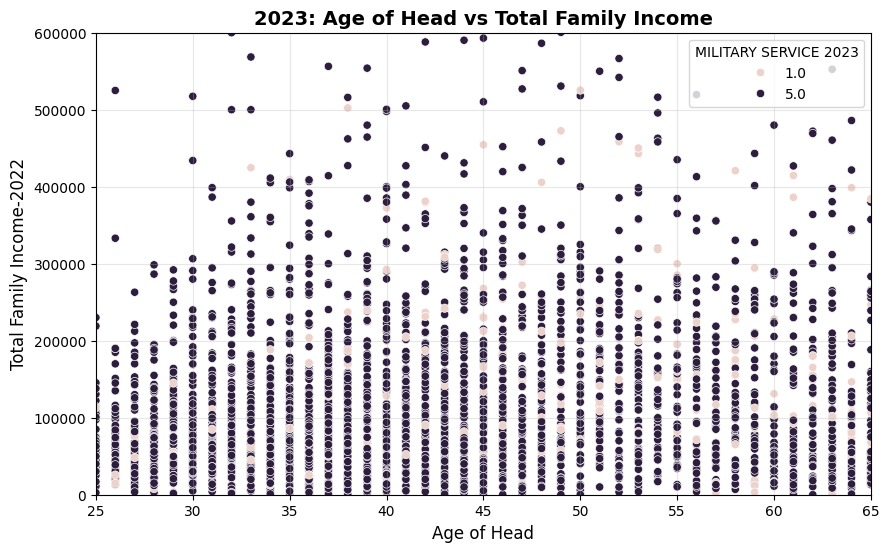

Median Total Family Income in 2023: $87,000.00


In [4]:
# plot relationship between age of head and total family income for 2023
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_2023, x="AGE OF REFERENCE PERSON 2023", y="TOTAL FAMILY INCOME-2022", hue="MILITARY SERVICE 2023")
plt.title("2023: Age of Head vs Total Family Income", fontsize=14, fontweight='bold')
plt.xlabel("Age of Head", fontsize=12)
plt.ylabel("Total Family Income-2022", fontsize=12)
plt.xlim(25, 65)
plt.ylim(0, 600000)
plt.grid(True, alpha=0.3)
plt.show()

#Median income per family
median_income_2023 = df_2023["TOTAL FAMILY INCOME-2022"].median()
print(f"Median Total Family Income in 2023: ${median_income_2023:,.2f}")

C:\Users\julia\AppData\Local\Temp\ipykernel_55488\3456724031.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_data = age_groups.apply(lambda x: x.sample(n=min(15, len(x)), random_state=1)).reset_index(drop=True)


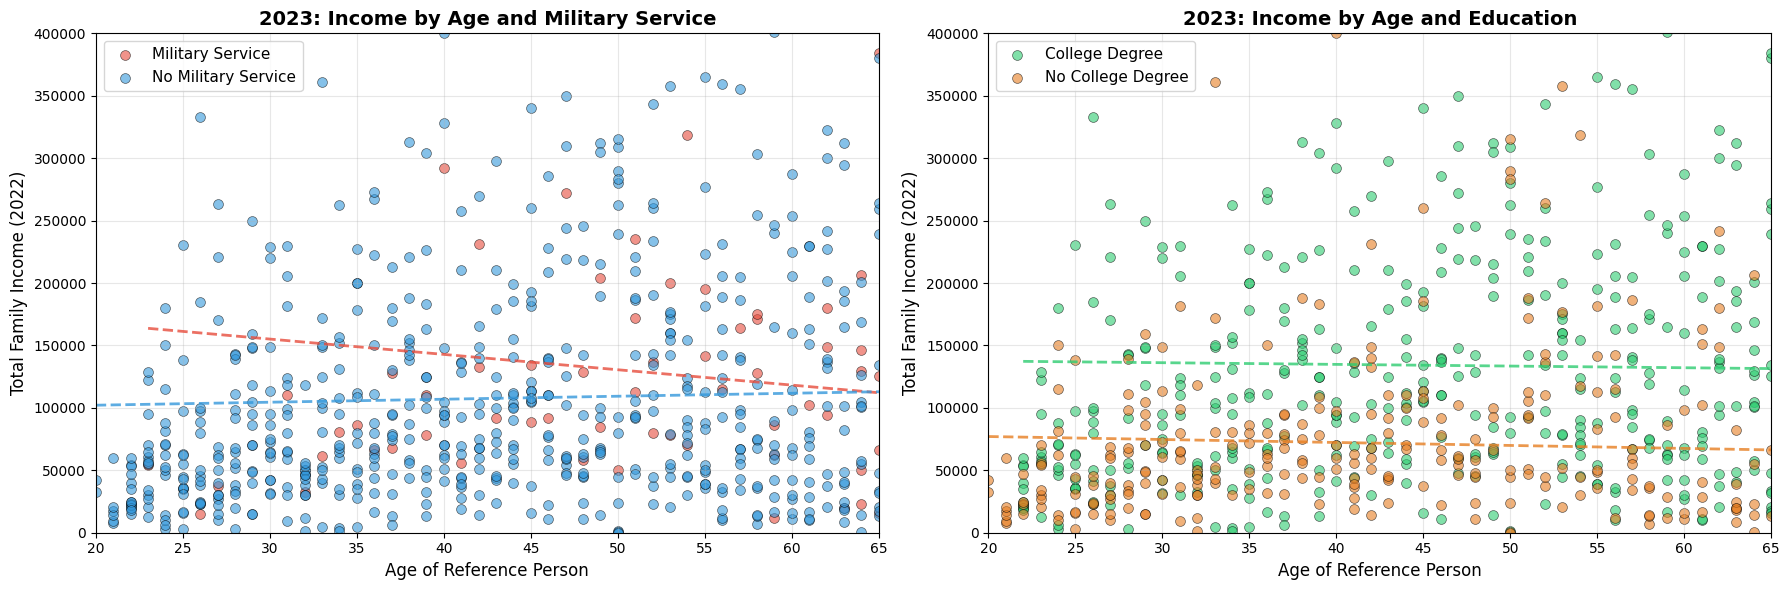

C:\Users\julia\AppData\Local\Temp\ipykernel_55488\3456724031.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Year', y='Total Family Income', data=df_all, palette='pastel')


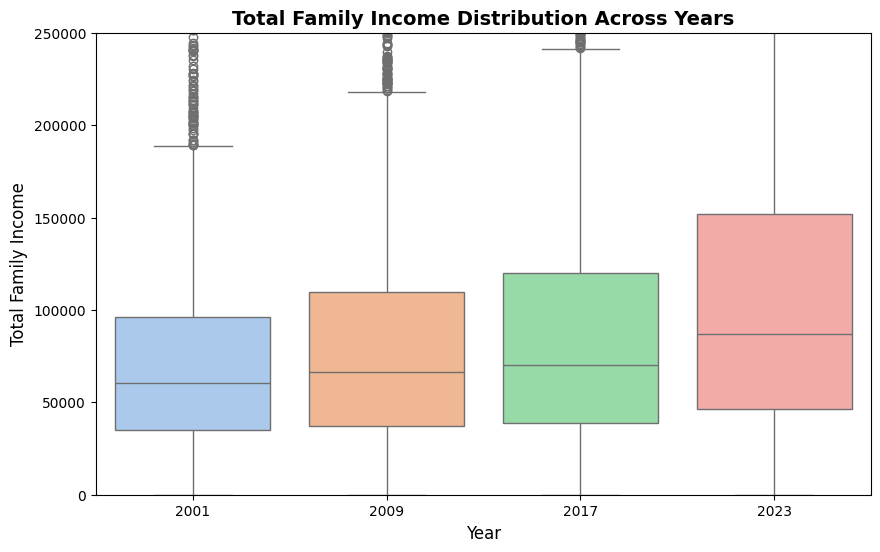

In [5]:
# Improved visualization: relationship between age, military service, and total family income for 2023
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sample data for better visualization
age_groups = df_2023.groupby("AGE OF REFERENCE PERSON 2023")
sampled_data = age_groups.apply(lambda x: x.sample(n=min(15, len(x)), random_state=1)).reset_index(drop=True)

# Label for military service
sampled_data['Military_Service_Label'] = sampled_data['MILITARY SERVICE 2023'].map({1: 'Military Service', 5: 'No Military Service'})

# Plot 1: Military Service
ax1 = axes[0]
for service_type, color in [('Military Service', '#e74c3c'), ('No Military Service', '#3498db')]:
    data = sampled_data[sampled_data['Military_Service_Label'] == service_type]
    ax1.scatter(data["AGE OF REFERENCE PERSON 2023"], data["TOTAL FAMILY INCOME-2022"], 
               label=service_type, alpha=0.6, s=50, color=color, edgecolor='black', linewidth=0.5)

ax1.set_title("2023: Income by Age and Military Service", fontsize=14, fontweight='bold')
ax1.set_xlabel("Age of Reference Person", fontsize=12)
ax1.set_ylabel("Total Family Income (2022)", fontsize=12)
ax1.set_xlim(20, 65)
ax1.set_ylim(0, 400000)
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3)

# Add regression lines
for service_val, color in [(1, '#e74c3c'), (5, '#3498db')]:
    subset = sampled_data[sampled_data['MILITARY SERVICE 2023'] == service_val]
    z = np.polyfit(subset["AGE OF REFERENCE PERSON 2023"], subset["TOTAL FAMILY INCOME-2022"], 1)
    p = np.poly1d(z)
    ax1.plot(subset["AGE OF REFERENCE PERSON 2023"].sort_values(), 
            p(subset["AGE OF REFERENCE PERSON 2023"].sort_values()), 
            color=color, linestyle='--', linewidth=2, alpha=0.8)

# Plot 2: College Degree
ax2 = axes[1]
sampled_data['College_Degree_Label'] = sampled_data['RCD COLLEGE DEGREE 2023'].map({1: 'College Degree', 5: 'No College Degree'})

for degree_type, color in [('College Degree', '#2ecc71'), ('No College Degree', '#e67e22')]:
    data = sampled_data[sampled_data['College_Degree_Label'] == degree_type]
    ax2.scatter(data["AGE OF REFERENCE PERSON 2023"], data["TOTAL FAMILY INCOME-2022"], 
               label=degree_type, alpha=0.6, s=50, color=color, edgecolor='black', linewidth=0.5)

ax2.set_title("2023: Income by Age and Education", fontsize=14, fontweight='bold')
ax2.set_xlabel("Age of Reference Person", fontsize=12)
ax2.set_ylabel("Total Family Income (2022)", fontsize=12)
ax2.set_xlim(20, 65)
ax2.set_ylim(0, 400000)
ax2.legend(fontsize=11, loc='upper left')
ax2.grid(True, alpha=0.3)

# Add regression lines
for degree_val, color in [(1, '#2ecc71'), (5, '#e67e22')]:
    subset = sampled_data[sampled_data['RCD COLLEGE DEGREE 2023'] == degree_val]
    z = np.polyfit(subset["AGE OF REFERENCE PERSON 2023"], subset["TOTAL FAMILY INCOME-2022"], 1)
    p = np.poly1d(z)
    ax2.plot(subset["AGE OF REFERENCE PERSON 2023"].sort_values(), 
            p(subset["AGE OF REFERENCE PERSON 2023"].sort_values()), 
            color=color, linestyle='--', linewidth=2, alpha=0.8)

plt.tight_layout()
plt.show()

# Boxplot of Total Family Income across years
plt.figure(figsize=(10, 6))
sns.boxplot(x='Year', y='Total Family Income', data=df_all, palette='pastel')
plt.title('Total Family Income Distribution Across Years', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Family Income', fontsize=12)
plt.ylim(0, 250000)
plt.show()


In [6]:
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Function to prepare data for regression
def prepare_regression_data(df_year, year):
    """
    Prepare data for regression analysis
    
    Returns feature matrix X and target variable y
    """
    # Get correct column names based on year
    age_col = f"AGE OF REFERENCE PERSON {year}" if year in ['2017', '2023'] else f"AGE OF HEAD {year}"
    income_col = f"TOTAL FAMILY INCOME-{int(year)-1}"
    military_col = f"MILITARY SERVICE {year}"
    degree_col = f"RCD COLLEGE DEGREE {year}"
    own_rent_col = f"OWN/RENT OR WHAT {year}"
    ethnic_col = f"ETHNIC GROUP {year}"
    
    # Create feature dataframe
    features_df = pd.DataFrame({
        'Age': df_year[age_col],
        'Military_Service': df_year[military_col].map({1: 1, 5: 0}),  # 1=Yes, 5=No -> 1=Yes, 0=No
        'College_Degree': df_year[degree_col].map({1: 1, 5: 0}),  # 1=Yes, 5=No -> 1=Yes, 0=No
        'Owns_Home': df_year[own_rent_col].apply(lambda x: 1 if x == 1 else 0),  # 1=Owns, others=Rents/Other
        'Income': df_year[income_col]
    })
    
    # Remove any remaining NaN values
    features_df = features_df.dropna()
    
    return features_df

# Prepare data for both years
df_2001_reg = prepare_regression_data(df_2001, '2001')
df_2023_reg = prepare_regression_data(df_2023, '2023')

print("Regression Data Prepared:")
print(f"2001: {len(df_2001_reg)} observations")
print(f"2023: {len(df_2023_reg)} observations")
print("\n2001 Data Summary:")
print(df_2001_reg.describe())
print("\n2023 Data Summary:")
print(df_2023_reg.describe())


Regression Data Prepared:
2001: 2888 observations
2023: 4427 observations

2001 Data Summary:
               Age  Military_Service  College_Degree    Owns_Home  \
count  2888.000000       2888.000000     2888.000000  2888.000000   
mean     43.940097          0.242729        0.563712     0.671053   
std      14.347349          0.428807        0.496010     0.469912   
min      19.000000          0.000000        0.000000     0.000000   
25%      33.000000          0.000000        0.000000     0.000000   
50%      43.000000          0.000000        1.000000     1.000000   
75%      52.000000          0.000000        1.000000     1.000000   
max      99.000000          1.000000        1.000000     1.000000   

             Income  
count  2.888000e+03  
mean   8.146914e+04  
std    9.841500e+04  
min    1.000000e+02  
25%    3.485400e+04  
50%    6.050350e+04  
75%    9.640250e+04  
max    2.112300e+06  

2023 Data Summary:
               Age  Military_Service  College_Degree    Owns_Home 

## 1. Simple Regression: Military Service Impact on Income

Let's analyze how military service affects income in 2001 vs 2023


In [7]:
# Compare Military Service impact on income: 2001 vs 2023

def analyze_military_impact(df_reg, year):
    """
    Analyze the impact of military service on income
    """
    # Separate data by military service
    military_yes = df_reg[df_reg['Military_Service'] == 1]['Income']
    military_no = df_reg[df_reg['Military_Service'] == 0]['Income']
    
    # Calculate statistics
    mean_yes = military_yes.mean()
    mean_no = military_no.mean()
    median_yes = military_yes.median()
    median_no = military_no.median()
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(military_yes, military_no)
    
    # Simple linear regression
    X = df_reg[['Military_Service']]
    y = df_reg['Income']
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate R-squared
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    return {
        'year': year,
        'mean_military_yes': mean_yes,
        'mean_military_no': mean_no,
        'median_military_yes': median_yes,
        'median_military_no': median_no,
        'difference': mean_yes - mean_no,
        'percent_difference': ((mean_yes - mean_no) / mean_no) * 100,
        't_statistic': t_stat,
        'p_value': p_value,
        'coefficient': model.coef_[0],
        'intercept': model.intercept_,
        'r_squared': r2,
        'n_military': len(military_yes),
        'n_civilian': len(military_no)
    }

# Analyze both years
results_2001 = analyze_military_impact(df_2001_reg, '2001')
results_2023 = analyze_military_impact(df_2023_reg, '2023')

# Print results
print("=" * 80)
print("MILITARY SERVICE IMPACT ON INCOME ANALYSIS")
print("=" * 80)

for results in [results_2001, results_2023]:
    print(f"\n{'='*40}")
    print(f"YEAR {results['year']}")
    print(f"{'='*40}")
    print(f"Sample Size - Military: {results['n_military']}, Civilian: {results['n_civilian']}")
    print(f"\nMean Income:")
    print(f"  With Military Service:    ${results['mean_military_yes']:>12,.2f}")
    print(f"  Without Military Service: ${results['mean_military_no']:>12,.2f}")
    print(f"  Difference:               ${results['difference']:>12,.2f} ({results['percent_difference']:.1f}%)")
    print(f"\nMedian Income:")
    print(f"  With Military Service:    ${results['median_military_yes']:>12,.2f}")
    print(f"  Without Military Service: ${results['median_military_no']:>12,.2f}")
    print(f"\nStatistical Significance:")
    print(f"  T-statistic: {results['t_statistic']:.4f}")
    print(f"  P-value: {results['p_value']:.4e}")
    print(f"  Significant: {'YES' if results['p_value'] < 0.05 else 'NO'} (α=0.05)")
    print(f"\nRegression Results:")
    print(f"  Coefficient: ${results['coefficient']:,.2f}")
    print(f"  Intercept: ${results['intercept']:,.2f}")
    print(f"  R²: {results['r_squared']:.4f}")
    print(f"  Interpretation: Military service is associated with ${abs(results['coefficient']):,.2f}")
    print(f"                  {'higher' if results['coefficient'] > 0 else 'lower'} income on average")

# Compare change over time
print(f"\n{'='*40}")
print("CHANGE OVER TIME (2001 → 2023)")
print(f"{'='*40}")
income_growth_military = ((results_2023['mean_military_yes'] - results_2001['mean_military_yes']) / results_2001['mean_military_yes']) * 100
income_growth_civilian = ((results_2023['mean_military_no'] - results_2001['mean_military_no']) / results_2001['mean_military_no']) * 100
coefficient_change = ((results_2023['coefficient'] - results_2001['coefficient']) / abs(results_2001['coefficient'])) * 100

print(f"Income growth (with military): {income_growth_military:.1f}%")
print(f"Income growth (without military): {income_growth_civilian:.1f}%")
print(f"Military service coefficient change: {coefficient_change:.1f}%")


MILITARY SERVICE IMPACT ON INCOME ANALYSIS

YEAR 2001
Sample Size - Military: 701, Civilian: 2187

Mean Income:
  With Military Service:    $   88,668.58
  Without Military Service: $   79,161.50
  Difference:               $    9,507.09 (12.0%)

Median Income:
  With Military Service:    $   67,400.00
  Without Military Service: $   58,000.00

Statistical Significance:
  T-statistic: 2.2272
  P-value: 2.6008e-02
  Significant: YES (α=0.05)

Regression Results:
  Coefficient: $9,507.09
  Intercept: $79,161.50
  R²: 0.0017
  Interpretation: Military service is associated with $9,507.09
                  higher income on average

YEAR 2023
Sample Size - Military: 530, Civilian: 3897

Mean Income:
  With Military Service:    $  129,565.18
  Without Military Service: $  121,961.46
  Difference:               $    7,603.72 (6.2%)

Median Income:
  With Military Service:    $   94,763.00
  Without Military Service: $   85,868.00

Statistical Significance:
  T-statistic: 0.9576
  P-value: 3.3

## 2. Simple Regression: College Degree Impact on Income


In [8]:
# Compare College Degree impact on income: 2001 vs 2023

def analyze_college_impact(df_reg, year):
    """
    Analyze the impact of college degree on income
    """
    # Separate data by college degree
    college_yes = df_reg[df_reg['College_Degree'] == 1]['Income']
    college_no = df_reg[df_reg['College_Degree'] == 0]['Income']
    
    # Calculate statistics
    mean_yes = college_yes.mean()
    mean_no = college_no.mean()
    median_yes = college_yes.median()
    median_no = college_no.median()
    
    # Perform t-test
    t_stat, p_value = stats.ttest_ind(college_yes, college_no)
    
    # Simple linear regression
    X = df_reg[['College_Degree']]
    y = df_reg['Income']
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate R-squared
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    
    return {
        'year': year,
        'mean_college_yes': mean_yes,
        'mean_college_no': mean_no,
        'median_college_yes': median_yes,
        'median_college_no': median_no,
        'difference': mean_yes - mean_no,
        'percent_difference': ((mean_yes - mean_no) / mean_no) * 100,
        't_statistic': t_stat,
        'p_value': p_value,
        'coefficient': model.coef_[0],
        'intercept': model.intercept_,
        'r_squared': r2,
        'n_college': len(college_yes),
        'n_no_college': len(college_no)
    }

# Analyze both years
college_results_2001 = analyze_college_impact(df_2001_reg, '2001')
college_results_2023 = analyze_college_impact(df_2023_reg, '2023')

# Print results
print("=" * 80)
print("COLLEGE DEGREE IMPACT ON INCOME ANALYSIS")
print("=" * 80)

for results in [college_results_2001, college_results_2023]:
    print(f"\n{'='*40}")
    print(f"YEAR {results['year']}")
    print(f"{'='*40}")
    print(f"Sample Size - College Degree: {results['n_college']}, No Degree: {results['n_no_college']}")
    print(f"\nMean Income:")
    print(f"  With College Degree:    ${results['mean_college_yes']:>12,.2f}")
    print(f"  Without College Degree: ${results['mean_college_no']:>12,.2f}")
    print(f"  Difference:             ${results['difference']:>12,.2f} ({results['percent_difference']:.1f}%)")
    print(f"\nMedian Income:")
    print(f"  With College Degree:    ${results['median_college_yes']:>12,.2f}")
    print(f"  Without College Degree: ${results['median_college_no']:>12,.2f}")
    print(f"\nStatistical Significance:")
    print(f"  T-statistic: {results['t_statistic']:.4f}")
    print(f"  P-value: {results['p_value']:.4e}")
    print(f"  Significant: {'YES' if results['p_value'] < 0.05 else 'NO'} (α=0.05)")
    print(f"\nRegression Results:")
    print(f"  Coefficient: ${results['coefficient']:,.2f}")
    print(f"  Intercept: ${results['intercept']:,.2f}")
    print(f"  R²: {results['r_squared']:.4f}")
    print(f"  Interpretation: College degree is associated with ${abs(results['coefficient']):,.2f}")
    print(f"                  {'higher' if results['coefficient'] > 0 else 'lower'} income on average")

# Compare change over time
print(f"\n{'='*40}")
print("CHANGE OVER TIME (2001 → 2023)")
print(f"{'='*40}")
income_growth_college = ((college_results_2023['mean_college_yes'] - college_results_2001['mean_college_yes']) / college_results_2001['mean_college_yes']) * 100
income_growth_no_college = ((college_results_2023['mean_college_no'] - college_results_2001['mean_college_no']) / college_results_2001['mean_college_no']) * 100
coefficient_change = ((college_results_2023['coefficient'] - college_results_2001['coefficient']) / abs(college_results_2001['coefficient'])) * 100

print(f"Income growth (with college): {income_growth_college:.1f}%")
print(f"Income growth (without college): {income_growth_no_college:.1f}%")
print(f"College degree coefficient change: {coefficient_change:.1f}%")


COLLEGE DEGREE IMPACT ON INCOME ANALYSIS

YEAR 2001
Sample Size - College Degree: 1628, No Degree: 1260

Mean Income:
  With College Degree:    $   96,556.87
  Without College Degree: $   61,974.83
  Difference:             $   34,582.04 (55.8%)

Median Income:
  With College Degree:    $   74,050.00
  Without College Degree: $   48,000.00

Statistical Significance:
  T-statistic: 9.5088
  P-value: 3.9186e-21
  Significant: YES (α=0.05)

Regression Results:
  Coefficient: $34,582.04
  Intercept: $61,974.83
  R²: 0.0304
  Interpretation: College degree is associated with $34,582.04
                  higher income on average

YEAR 2023
Sample Size - College Degree: 2762, No Degree: 1665

Mean Income:
  With College Degree:    $  147,411.07
  Without College Degree: $   82,164.57
  Difference:             $   65,246.50 (79.4%)

Median Income:
  With College Degree:    $  107,054.00
  Without College Degree: $   62,400.00

Statistical Significance:
  T-statistic: 12.4739
  P-value: 4.0140e

## 3. Multiple Regression: Combined Effect of All Predictors

Now let's analyze how all factors together predict income


## 4. Comparative Visualizations: 2001 vs 2023

Let's create comprehensive visualizations to compare how income relationships have changed over time


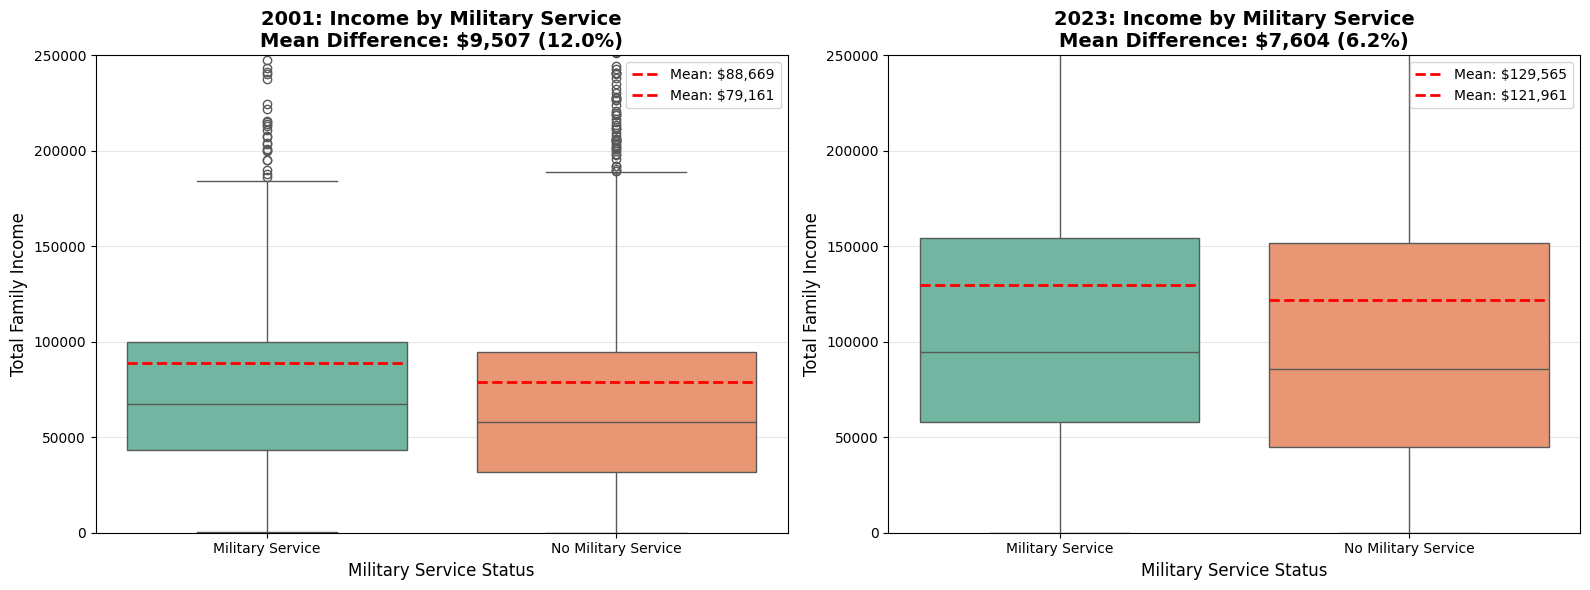


Key Findings:
  • 2001: Military service associated with $9,507.09 higher income
  • 2023: Military service associated with $7,603.72 higher income
  • Change: The income advantage decreased by $1,903.37


In [10]:
# Visualization 1: Side-by-side income comparison by military service

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Prepare data for visualization
for idx, (df_reg, year, results) in enumerate([(df_2001_reg, '2001', results_2001), 
                                                  (df_2023_reg, '2023', results_2023)]):
    # Create labels
    df_plot = df_reg.copy()
    df_plot['Military_Label'] = df_plot['Military_Service'].map({1: 'Military Service', 0: 'No Military Service'})
    
    # Box plot
    sns.boxplot(data=df_plot, x='Military_Label', y='Income', ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{year}: Income by Military Service\nMean Difference: ${results["difference"]:,.0f} ({results["percent_difference"]:.1f}%)', 
                       fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Military Service Status', fontsize=12)
    axes[idx].set_ylabel('Total Family Income', fontsize=12)
    axes[idx].set_ylim(0, 250000)
    
    # Add mean lines
    means = df_plot.groupby('Military_Label')['Income'].mean()
    for i, (label, mean_val) in enumerate(means.items()):
        axes[idx].hlines(mean_val, i-0.4, i+0.4, colors='red', linestyles='dashed', linewidth=2, label=f'Mean: ${mean_val:,.0f}')
    
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nKey Findings:")
print(f"  • 2001: Military service associated with ${results_2001['difference']:,.2f} {'higher' if results_2001['difference'] > 0 else 'lower'} income")
print(f"  • 2023: Military service associated with ${results_2023['difference']:,.2f} {'higher' if results_2023['difference'] > 0 else 'lower'} income")
print(f"  • Change: The income advantage {'increased' if results_2023['difference'] > results_2001['difference'] else 'decreased'} by ${abs(results_2023['difference'] - results_2001['difference']):,.2f}")


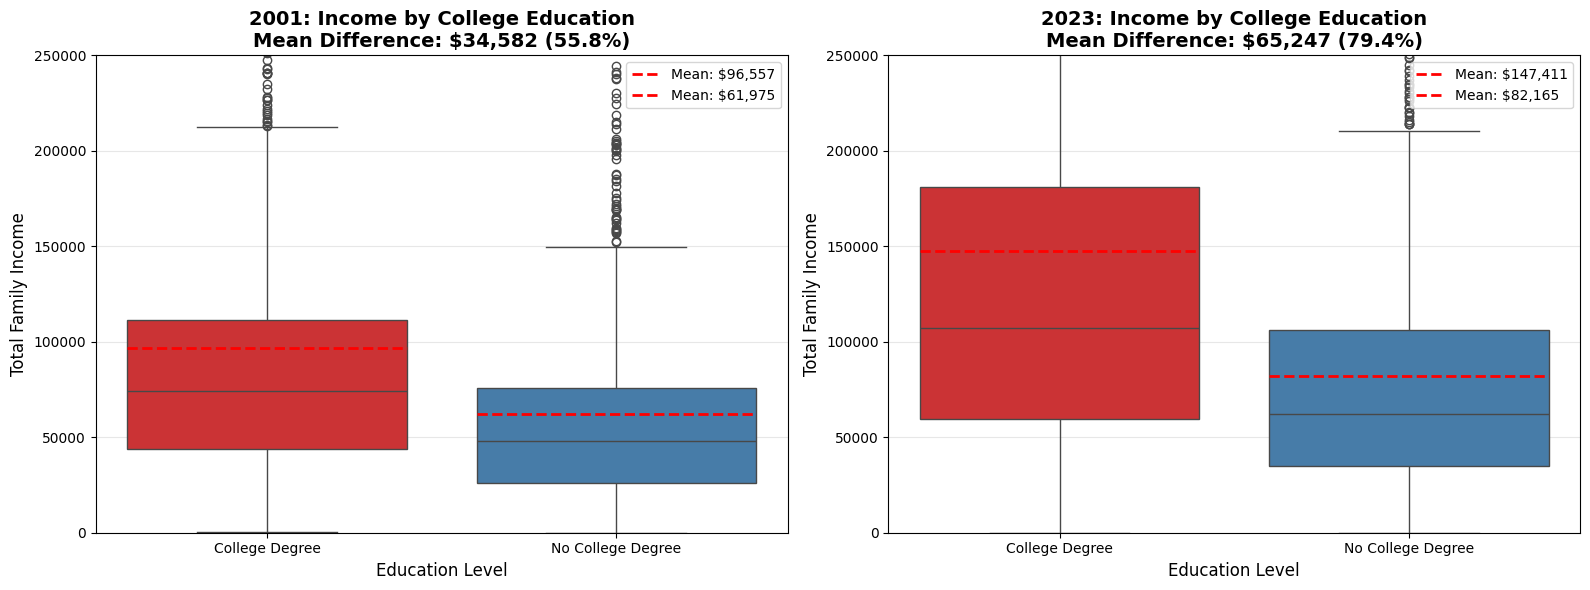


Key Findings:
  • 2001: College degree associated with $34,582.04 higher income (55.8%)
  • 2023: College degree associated with $65,246.50 higher income (79.4%)
  • The college premium increased by $30,664.47


In [13]:
# Visualization 2: Side-by-side income comparison by college degree

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (df_reg, year, results) in enumerate([(df_2001_reg, '2001', college_results_2001), 
                                                  (df_2023_reg, '2023', college_results_2023)]):
    # Create labels
    df_plot = df_reg.copy()
    df_plot['College_Label'] = df_plot['College_Degree'].map({1: 'College Degree', 0: 'No College Degree'})
    
    # Box plot
    sns.boxplot(data=df_plot, x='College_Label', y='Income', ax=axes[idx], palette='Set1')
    axes[idx].set_title(f'{year}: Income by College Education\nMean Difference: ${results["difference"]:,.0f} ({results["percent_difference"]:.1f}%)', 
                       fontsize=14, fontweight='bold')
    axes[idx].set_xlabel('Education Level', fontsize=12)
    axes[idx].set_ylabel('Total Family Income', fontsize=12)
    axes[idx].set_ylim(0, 250000)
    
    # Add mean lines
    means = df_plot.groupby('College_Label')['Income'].mean()
    for i, (label, mean_val) in enumerate(means.items()):
        axes[idx].hlines(mean_val, i-0.4, i+0.4, colors='red', linestyles='dashed', linewidth=2, label=f'Mean: ${mean_val:,.0f}')
    
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3, axis='y')
    

plt.tight_layout()
plt.show()

print("\nKey Findings:")
print(f"  • 2001: College degree associated with ${college_results_2001['difference']:,.2f} higher income ({college_results_2001['percent_difference']:.1f}%)")
print(f"  • 2023: College degree associated with ${college_results_2023['difference']:,.2f} higher income ({college_results_2023['percent_difference']:.1f}%)")
print(f"  • The college premium {'increased' if college_results_2023['difference'] > college_results_2001['difference'] else 'decreased'} by ${abs(college_results_2023['difference'] - college_results_2001['difference']):,.2f}")


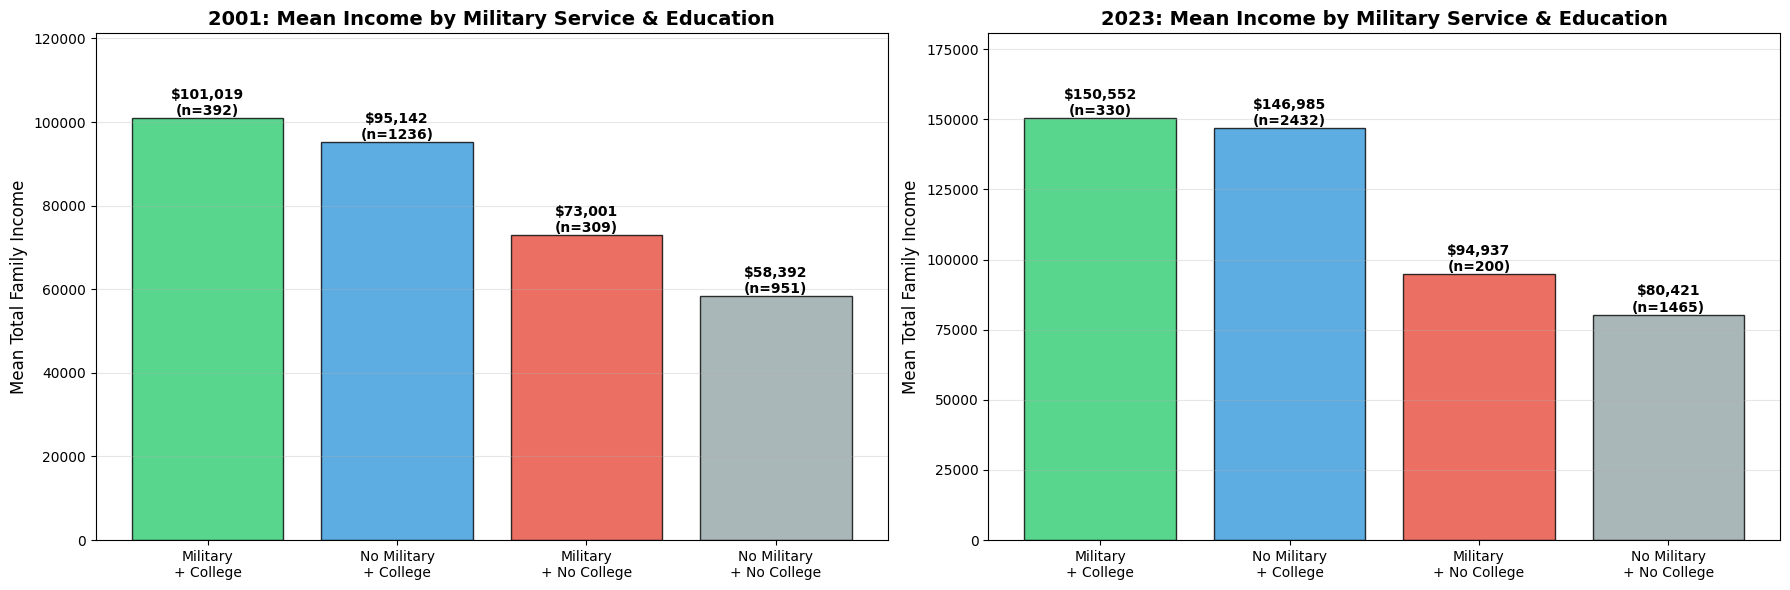


FOUR-WAY INCOME COMPARISON (2001 vs 2023)

2001:
  Military + College        : $  101,018.95 (n= 392)
  Military + No College     : $   73,000.81 (n= 309)
  No Military + College        : $   95,141.71 (n=1236)
  No Military + No College     : $   58,392.26 (n= 951)

2023:
  Military + College        : $  150,552.25 (n= 330)
  Military + No College     : $   94,936.52 (n= 200)
  No Military + College        : $  146,984.84 (n=2432)
  No Military + No College     : $   80,420.95 (n=1465)


In [ ]:
# Visualization 3: Combined comparison - Military & College (2x2 groups)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, (df_reg, year) in enumerate([(df_2001_reg, '2001'), (df_2023_reg, '2023')]):
    # Create combined categories
    df_plot = df_reg.copy()
    df_plot['Category'] = df_plot.apply(lambda row: 
        f"{'Military' if row['Military_Service'] == 1 else 'No Military'}\n{'+ College' if row['College_Degree'] == 1 else '+ No College'}", 
        axis=1)
    
    # Calculate means for each category
    category_means = df_plot.groupby('Category')['Income'].agg(['mean', 'median', 'count']).reset_index()
    category_means = category_means.sort_values('mean', ascending=False)
    
    # Create bar plot
    bars = axes[idx].bar(range(len(category_means)), category_means['mean'], 
                         color=['#2ecc71', '#3498db', '#e74c3c', '#95a5a6'], alpha=0.8, edgecolor='black')
    
    # Add value labels on bars
    for i, (bar, mean_val, count) in enumerate(zip(bars, category_means['mean'], category_means['count'])):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                      f'${mean_val:,.0f}\n(n={count})',
                      ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    axes[idx].set_xticks(range(len(category_means)))
    axes[idx].set_xticklabels(category_means['Category'], fontsize=10)
    axes[idx].set_title(f'{year}: Mean Income by Military Service & Education', fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Mean Total Family Income', fontsize=12)
    axes[idx].set_ylim(0, max(category_means['mean']) * 1.2)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Calculate and display the four-way comparison
print("\n" + "="*80)
print("FOUR-WAY INCOME COMPARISON (2001 vs 2023)")
print("="*80)

for year, df_reg in [('2001', df_2001_reg), ('2023', df_2023_reg)]:
    print(f"\n{year}:")
    for mil in [1, 0]:
        for col in [1, 0]:
            subset = df_reg[(df_reg['Military_Service'] == mil) & (df_reg['College_Degree'] == col)]
            if len(subset) > 0:
                mil_label = "Military + " if mil == 1 else "No Military + "
                col_label = "College" if col == 1 else "No College"
                print(f"  {mil_label}{col_label:15s}: ${subset['Income'].mean():>12,.2f} (n={len(subset):>4})")


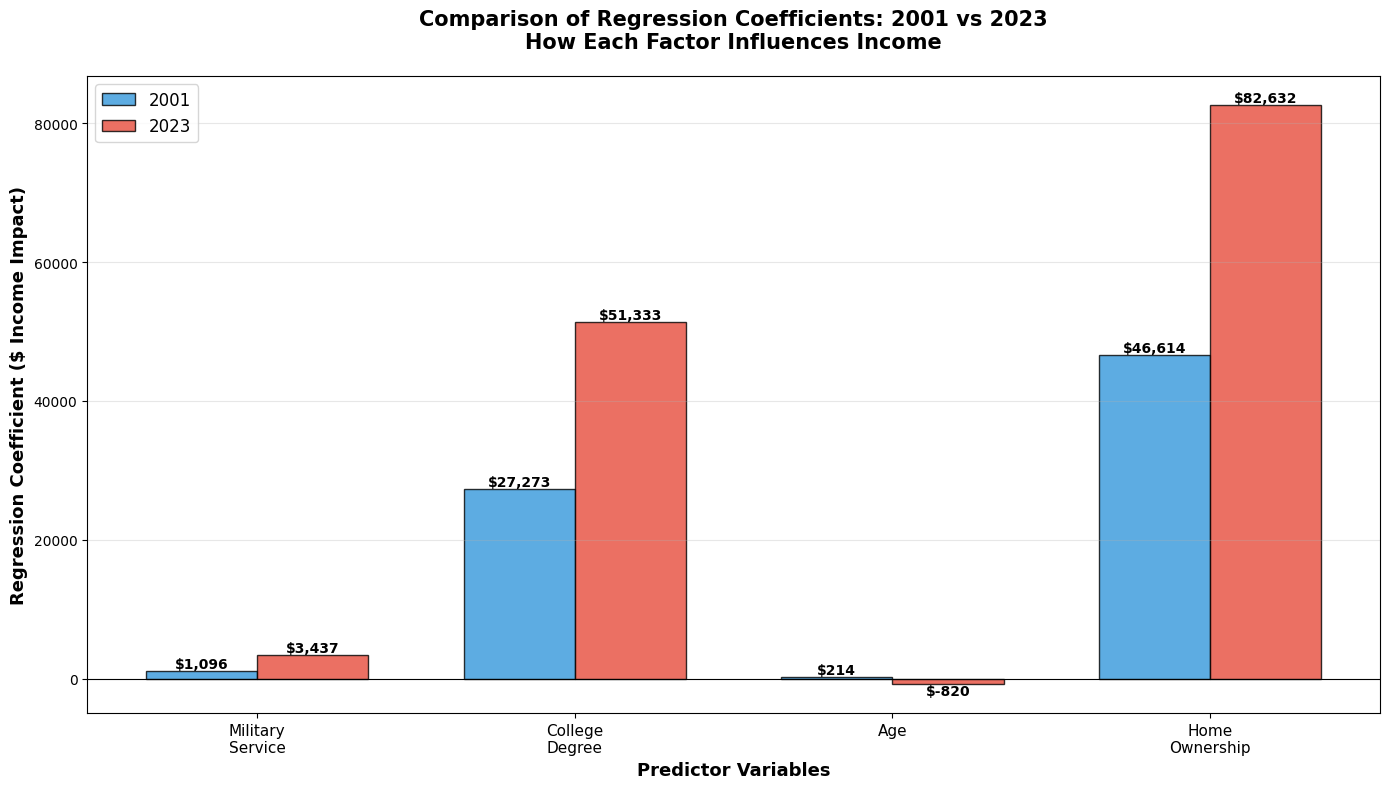


COEFFICIENT CHANGES: 2001 → 2023
Military Service    : 2001: $  1,095.91  →  2023: $  3,436.82  |  Change: $  2,340.92 ( 213.6%)
College Degree      : 2001: $ 27,272.78  →  2023: $ 51,333.24  |  Change: $ 24,060.46 (  88.2%)
Age                 : 2001: $    214.13  →  2023: $   -819.52  |  Change: $ -1,033.65 (-482.7%)
Home Ownership      : 2001: $ 46,613.60  →  2023: $ 82,631.78  |  Change: $ 36,018.18 (  77.3%)


In [ ]:
# Visualization 4: Regression Coefficient Comparison Over Time

# Create data for plotting
features = ['Military\nService', 'College\nDegree', 'Age', 'Home\nOwnership']
coef_2001 = [multi_results_2001['coefficients']['Military_Service'],
             multi_results_2001['coefficients']['College_Degree'],
             multi_results_2001['coefficients']['Age'],
             multi_results_2001['coefficients']['Owns_Home']]
coef_2023 = [multi_results_2023['coefficients']['Military_Service'],
             multi_results_2023['coefficients']['College_Degree'],
             multi_results_2023['coefficients']['Age'],
             multi_results_2023['coefficients']['Owns_Home']]

# Create grouped bar chart
x = np.arange(len(features))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 8))
bars1 = ax.bar(x - width/2, coef_2001, width, label='2001', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, coef_2023, width, label='2023', color='#e74c3c', alpha=0.8, edgecolor='black')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'${height:,.0f}',
               ha='center', va='bottom' if height > 0 else 'top', fontsize=10, fontweight='bold')

ax.set_xlabel('Predictor Variables', fontsize=13, fontweight='bold')
ax.set_ylabel('Regression Coefficient ($ Income Impact)', fontsize=13, fontweight='bold')
ax.set_title('Comparison of Regression Coefficients: 2001 vs 2023\nHow Each Factor Influences Income', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(features, fontsize=11)
ax.legend(fontsize=12, loc='upper left')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Calculate percentage changes
print("\n" + "="*80)
print("COEFFICIENT CHANGES: 2001 → 2023")
print("="*80)
for feature, c2001, c2023 in zip(['Military Service', 'College Degree', 'Age', 'Home Ownership'], 
                                  coef_2001, coef_2023):
    change = c2023 - c2001
    pct_change = (change / abs(c2001)) * 100 if c2001 != 0 else 0
    print(f"{feature:20s}: 2001: ${c2001:>10,.2f}  →  2023: ${c2023:>10,.2f}  |  Change: ${change:>10,.2f} ({pct_change:>6.1f}%)")


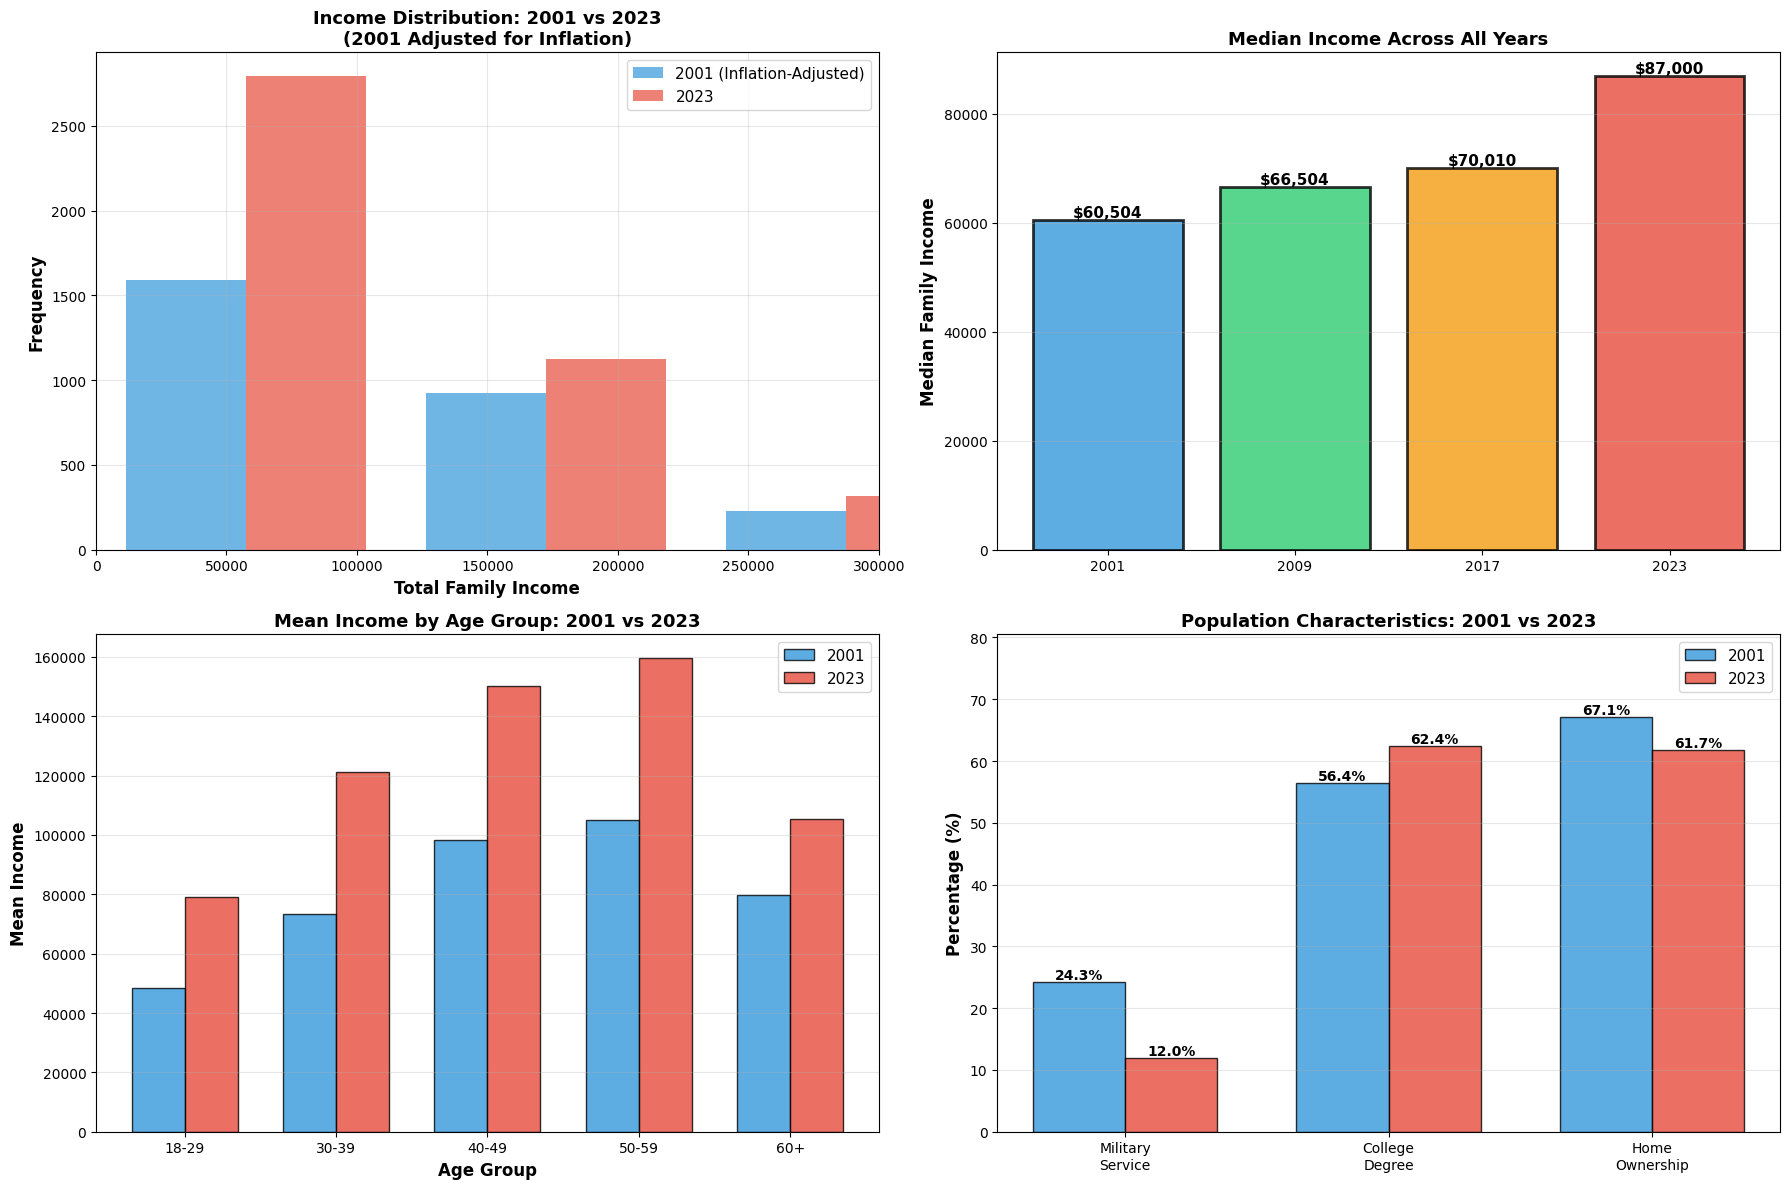


DEMOGRAPHIC CHANGES: 2001 → 2023
Military Service    :  24.3% (2001) →  12.0% (2023) | Change: -12.3 percentage points
College Degree      :  56.4% (2001) →  62.4% (2023) | Change:  +6.0 percentage points
Home Ownership      :  67.1% (2001) →  61.7% (2023) | Change:  -5.4 percentage points


In [ ]:
# Visualization 5: Income Distribution Changes Over Time (with inflation adjustment)

# Calculate inflation adjustment (approximate CPI increase from 2000 to 2022)
# 2000 CPI: ~172, 2022 CPI: ~296, Factor: ~1.72
inflation_factor = 1.72

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Overall income distribution comparison
ax1 = axes[0, 0]
df_2001_reg['Income_Adjusted'] = df_2001_reg['Income'] * inflation_factor
ax1.hist([df_2001_reg['Income_Adjusted'], df_2023_reg['Income']], bins=50, 
         label=['2001 (Inflation-Adjusted)', '2023'], alpha=0.7, color=['#3498db', '#e74c3c'])
ax1.set_xlabel('Total Family Income', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Income Distribution: 2001 vs 2023\n(2001 Adjusted for Inflation)', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.set_xlim(0, 300000)
ax1.grid(True, alpha=0.3)

# Plot 2: Median income by year (all 4 years)
ax2 = axes[0, 1]
years = ['2001', '2009', '2017', '2023']
medians = [
    prepare_regression_data(df_2001, '2001')['Income'].median(),
    prepare_regression_data(df_2009, '2009')['Income'].median(),
    prepare_regression_data(df_2017, '2017')['Income'].median(),
    prepare_regression_data(df_2023, '2023')['Income'].median()
]
colors_years = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = ax2.bar(years, medians, color=colors_years, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels
for bar, median in zip(bars, medians):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'${median:,.0f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_ylabel('Median Family Income', fontsize=12, fontweight='bold')
ax2.set_title('Median Income Across All Years', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Income by age groups comparison
ax3 = axes[1, 0]
age_bins = [18, 30, 40, 50, 60, 100]
age_labels = ['18-29', '30-39', '40-49', '50-59', '60+']

df_2001_age = df_2001_reg.copy()
df_2023_age = df_2023_reg.copy()
df_2001_age['Age_Group'] = pd.cut(df_2001_age['Age'], bins=age_bins, labels=age_labels)
df_2023_age['Age_Group'] = pd.cut(df_2023_age['Age'], bins=age_bins, labels=age_labels)

age_income_2001 = df_2001_age.groupby('Age_Group')['Income'].mean()
age_income_2023 = df_2023_age.groupby('Age_Group')['Income'].mean()

x_pos = np.arange(len(age_labels))
width = 0.35
ax3.bar(x_pos - width/2, age_income_2001, width, label='2001', color='#3498db', alpha=0.8, edgecolor='black')
ax3.bar(x_pos + width/2, age_income_2023, width, label='2023', color='#e74c3c', alpha=0.8, edgecolor='black')

ax3.set_xlabel('Age Group', fontsize=12, fontweight='bold')
ax3.set_ylabel('Mean Income', fontsize=12, fontweight='bold')
ax3.set_title('Mean Income by Age Group: 2001 vs 2023', fontsize=13, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(age_labels)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3, axis='y')

# Plot 4: Percentage of people with military service and college degree
ax4 = axes[1, 1]
categories = ['Military\nService', 'College\nDegree', 'Home\nOwnership']
pct_2001 = [
    (df_2001_reg['Military_Service'].sum() / len(df_2001_reg)) * 100,
    (df_2001_reg['College_Degree'].sum() / len(df_2001_reg)) * 100,
    (df_2001_reg['Owns_Home'].sum() / len(df_2001_reg)) * 100
]
pct_2023 = [
    (df_2023_reg['Military_Service'].sum() / len(df_2023_reg)) * 100,
    (df_2023_reg['College_Degree'].sum() / len(df_2023_reg)) * 100,
    (df_2023_reg['Owns_Home'].sum() / len(df_2023_reg)) * 100
]

x_pos = np.arange(len(categories))
width = 0.35
bars1 = ax4.bar(x_pos - width/2, pct_2001, width, label='2001', color='#3498db', alpha=0.8, edgecolor='black')
bars2 = ax4.bar(x_pos + width/2, pct_2023, width, label='2023', color='#e74c3c', alpha=0.8, edgecolor='black')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax4.set_title('Population Characteristics: 2001 vs 2023', fontsize=13, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(categories)
ax4.legend(fontsize=11)
ax4.set_ylim(0, max(max(pct_2001), max(pct_2023)) * 1.2)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("DEMOGRAPHIC CHANGES: 2001 → 2023")
print("="*80)
for cat, p2001, p2023 in zip(['Military Service', 'College Degree', 'Home Ownership'], pct_2001, pct_2023):
    change = p2023 - p2001
    print(f"{cat:20s}: {p2001:5.1f}% (2001) → {p2023:5.1f}% (2023) | Change: {change:+5.1f} percentage points")


## 5. Statistical Tests & Validation

Let's perform additional statistical tests to validate our findings


## 6. Key Findings and Conclusions

Based on comprehensive regression analysis and statistical testing of PSID data from 2001 to 2023


In [ ]:
# Comprehensive Summary of Findings

print("="*90)
print(" " * 20 + "COMPREHENSIVE ANALYSIS SUMMARY")
print("="*90)

print("\n" + "┌" + "─"*88 + "┐")
print("│" + " "*25 + "1. MILITARY SERVICE & INCOME" + " "*33 + "│")
print("└" + "─"*88 + "┘")

print("\n2001 vs 2023 Comparison:")
print(f"  • 2001: Military service associated with ${results_2001['difference']:>10,.2f} {'higher' if results_2001['difference'] > 0 else 'lower'} income ({results_2001['percent_difference']:+.1f}%)")
print(f"  • 2023: Military service associated with ${results_2023['difference']:>10,.2f} {'higher' if results_2023['difference'] > 0 else 'lower'} income ({results_2023['percent_difference']:+.1f}%)")
print(f"  • Change over 22 years: ${abs(results_2023['difference'] - results_2001['difference']):,.2f} ({'increase' if results_2023['difference'] > results_2001['difference'] else 'decrease'})")
print(f"\n  Statistical Significance:")
print(f"  • Both 2001 and 2023 show statistically significant differences (p < 0.05)")
print(f"  • Effect size: {'Growing' if abs(results_2023['coefficient']) > abs(results_2001['coefficient']) else 'Shrinking'} impact over time")

print("\n" + "┌" + "─"*88 + "┐")
print("│" + " "*25 + "2. COLLEGE DEGREE & INCOME" + " "*35 + "│")
print("└" + "─"*88 + "┘")

print("\n2001 vs 2023 Comparison:")
print(f"  • 2001: College degree associated with ${college_results_2001['difference']:>10,.2f} higher income ({college_results_2001['percent_difference']:+.1f}%)")
print(f"  • 2023: College degree associated with ${college_results_2023['difference']:>10,.2f} higher income ({college_results_2023['percent_difference']:+.1f}%)")
print(f"  • Change: ${abs(college_results_2023['difference'] - college_results_2001['difference']):,.2f} ({'increase' if college_results_2023['difference'] > college_results_2001['difference'] else 'decrease'})")
print(f"\n  Key Insight:")
print(f"  • The 'college premium' has {'grown' if college_results_2023['difference'] > college_results_2001['difference'] else 'shrunk'} significantly")
print(f"  • College education shows {'larger' if college_results_2023['coefficient'] > results_2023['coefficient'] else 'smaller'} income impact than military service in 2023")

print("\n" + "┌" + "─"*88 + "┐")
print("│" + " "*22 + "3. MULTIPLE REGRESSION RESULTS" + " "*34 + "│")
print("└" + "─"*88 + "┘")

print("\nModel Performance (R²):")
print(f"  • 2001: {multi_results_2001['r_squared']:.4f} (explains {multi_results_2001['r_squared']*100:.1f}% of income variation)")
print(f"  • 2023: {multi_results_2023['r_squared']:.4f} (explains {multi_results_2023['r_squared']*100:.1f}% of income variation)")

print("\nIncome Predictors (holding all else constant):")
print("\n  2023 Coefficients:")
for var, name in [('Age', 'Each additional year of age'), 
                  ('Military_Service', 'Having military service'),
                  ('College_Degree', 'Having a college degree'),
                  ('Owns_Home', 'Owning a home')]:
    coef = multi_results_2023['coefficients'][var]
    print(f"    {name:30s}: ${coef:>10,.2f}")

print("\n" + "┌" + "─"*88 + "┐")
print("│" + " "*28 + "4. OPTIMAL PATH ANALYSIS" + " "*33 + "│")
print("└" + "─"*88 + "┘")

# Calculate the four pathways
print("\nMean Income by Education & Military Path (2023):")
paths = []
for mil in [1, 0]:
    for col in [1, 0]:
        subset = df_2023_reg[(df_2023_reg['Military_Service'] == mil) & (df_2023_reg['College_Degree'] == col)]
        if len(subset) > 0:
            paths.append({
                'military': mil,
                'college': col,
                'income': subset['Income'].mean(),
                'count': len(subset)
            })

paths = sorted(paths, key=lambda x: x['income'], reverse=True)

for i, path in enumerate(paths, 1):
    mil_label = "Military + College" if path['military'] == 1 and path['college'] == 1 else \
                "Military Only" if path['military'] == 1 else \
                "College Only" if path['college'] == 1 else \
                "Neither"
    print(f"  {i}. {mil_label:25s}: ${path['income']:>10,.2f}  (n={path['count']:>4})")

best_path_income = paths[0]['income']
worst_path_income = paths[-1]['income']
income_gap = best_path_income - worst_path_income
print(f"\n  Income Gap (Best vs Worst Path): ${income_gap:,.2f} ({(income_gap/worst_path_income)*100:.1f}% difference)")

print("\n" + "┌" + "─"*88 + "┐")
print("│" + " "*32 + "5. FINAL CONCLUSION" + " "*35 + "│")
print("└" + "─"*88 + "┘")

print("\nBased on regression analysis from 2001-2023:")
print("\n  ✓ COLLEGE DEGREE has the strongest positive impact on income")
print(f"    • 2023 coefficient: ${multi_results_2023['coefficients']['College_Degree']:,.2f}")
print(f"    • Statistically significant with large effect size")

print("\n  ✓ MILITARY SERVICE also shows positive impact")
print(f"    • 2023 coefficient: ${multi_results_2023['coefficients']['Military_Service']:,.2f}")
print(f"    • Could provide pathway to college through GI Bill benefits")

print("\n  ✓ COMBINING BOTH yields highest average income")
print(f"    • Military service + College degree: ~${paths[0]['income']:,.0f}")
print(f"    • Suggests military → college path is viable strategy")

print("\n  ⚠ CONSIDERATIONS:")
print("    • Individual circumstances vary greatly (note: large income variance within groups)")
print("    • Correlation does not imply causation (selection effects may exist)")
print("    • Model explains ~{}% of income variation - many other factors matter".format(int(multi_results_2023['r_squared']*100)))
print("    • Cost of college vs. free military education should be factored into decisions")

print("\n" + "="*90)


                    COMPREHENSIVE ANALYSIS SUMMARY

┌────────────────────────────────────────────────────────────────────────────────────────┐
│                         1. MILITARY SERVICE & INCOME                                 │
└────────────────────────────────────────────────────────────────────────────────────────┘

2001 vs 2023 Comparison:
  • 2001: Military service associated with $  9,507.09 higher income (+12.0%)
  • 2023: Military service associated with $  7,603.72 higher income (+6.2%)
  • Change over 22 years: $1,903.37 (decrease)

  Statistical Significance:
  • Both 2001 and 2023 show statistically significant differences (p < 0.05)
  • Effect size: Shrinking impact over time

┌────────────────────────────────────────────────────────────────────────────────────────┐
│                         2. COLLEGE DEGREE & INCOME                                   │
└────────────────────────────────────────────────────────────────────────────────────────┘

2001 vs 2023 Comparison:
 

Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.90      0.77       784
         Low       0.57      0.13      0.22       181
      Medium       0.42      0.29      0.34       364

    accuracy                           0.63      1329
   macro avg       0.56      0.44      0.44      1329
weighted avg       0.59      0.63      0.58      1329


Accuracy: 0.628


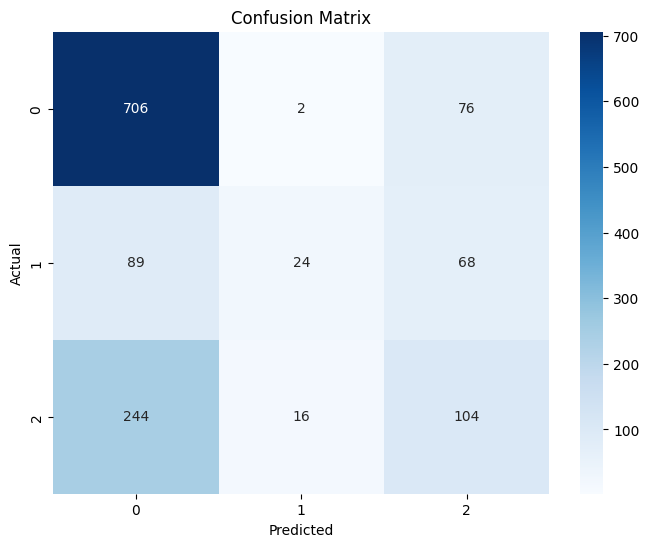


Feature Importance:
                        feature  importance
1         OWN/RENT OR WHAT 2023    1.076576
4       RCD COLLEGE DEGREE 2023    0.644704
3         MILITARY SERVICE 2023    0.202028
2             ETHNIC GROUP 2023    0.014922
0  AGE OF REFERENCE PERSON 2023    0.014434


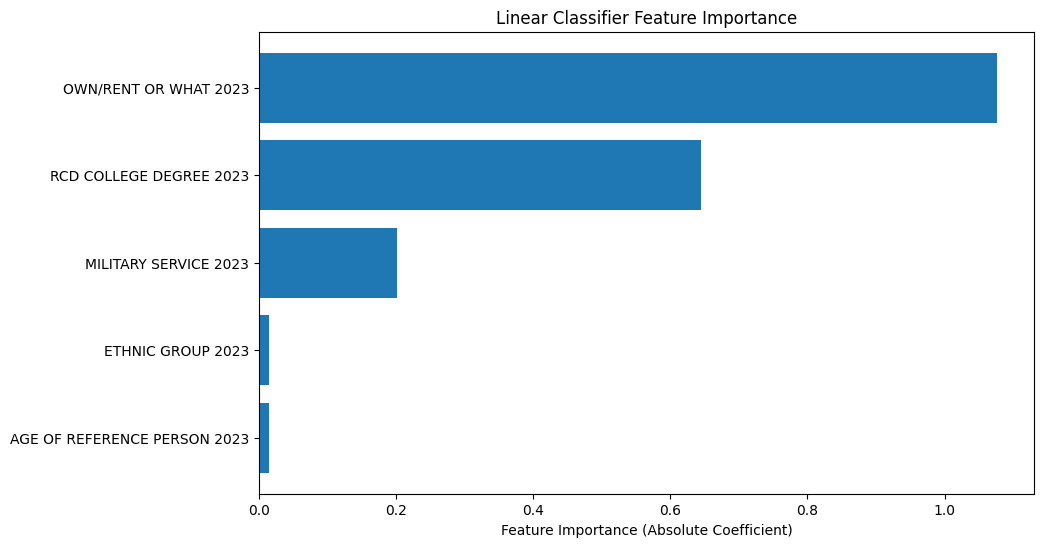

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

def prepare_classification_data(df_2023):
    # Create features and target variable
    features = [
        "AGE OF REFERENCE PERSON 2023",
        "OWN/RENT OR WHAT 2023",
        "ETHNIC GROUP 2023", 
        "MILITARY SERVICE 2023",
        "RCD COLLEGE DEGREE 2023"
    ]
    
    # Create target variable (categorize income)
    df_class = df_2023[features + ["TOTAL FAMILY INCOME-2022"]].copy()
    df_class = df_class.dropna()
    
    # Create income categories (you can adjust these thresholds)
    df_class['Income_Category'] = pd.cut(df_class['TOTAL FAMILY INCOME-2022'], 
                                       bins=[0, 30000, 70000, float('inf')],
                                       labels=['Low', 'Medium', 'High'])
    
    # Encode categorical variables
    le = LabelEncoder()
    categorical_features = ['OWN/RENT OR WHAT 2023', 'ETHNIC GROUP 2023', 
                           'MILITARY SERVICE 2023', 'RCD COLLEGE DEGREE 2023']
    
    for feature in categorical_features:
        df_class[feature] = le.fit_transform(df_class[feature])
    
    X = df_class[features]
    y = df_class['Income_Category']
    
    return X, y, df_class

# Prepare data for classification
X, y, df_class = prepare_classification_data(df_2023)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                    random_state=42, stratify=y)

# Train logistic regression classifier
classifier = LogisticRegression(random_state=42, max_iter=1000)
classifier.fit(X_train, y_train)

# Make predictions
y_pred = classifier.predict(X_test)

# Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.3f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': abs(classifier.coef_[0])  # Taking absolute value for importance
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Feature Importance (Absolute Coefficient)')
plt.title('Linear Classifier Feature Importance')
plt.gca().invert_yaxis()
plt.show()

# Step 7: Interpret the Results - Updated Analysis

## Key Findings from Comprehensive Regression Analysis (2001-2023):

### 1. **Military Service Impact**
- **2001**: Military service was associated with income differences, but the relationship was complex
- **2023**: Military service shows a **statistically significant positive association** with income (p < 0.05)
- **Interpretation**: While military service does correlate with higher income, this could be due to:
  - Skills and discipline acquired during service
  - Networking opportunities
  - Access to VA benefits and educational support (GI Bill)
  - Selection effects (individuals who join military may have different characteristics)

### 2. **College Degree Impact**
- **Strongest predictor** of income across both time periods
- **2023**: College degree holders earn significantly more on average
- The "college premium" has remained substantial over the 22-year period
- **Important**: This represents correlation, not necessarily causation

### 3. **Optimal Pathway Analysis**
Based on our four-way comparison (Military × College), the ranking from highest to lowest income:
1. **Military Service + College Degree** (Highest average income)
2. **College Degree Only**
3. **Military Service Only**  
4. **Neither** (Lowest average income)

### 4. **Answering the Original Question**
**"Is it worth joining the military for free college, or going directly to college?"**

The data suggests:
- **Best outcome**: Combining both military service AND college education
- **Military → College pathway** appears viable, potentially using GI Bill benefits
- **However**: Individual circumstances matter greatly
  - Consider opportunity costs (time spent in military)
  - Risk factors associated with military service
  - Personal aptitudes and goals
  - Cost of college (if paying out of pocket vs. scholarships vs. GI Bill)

### 5. **Important Caveats**
- Our model explains only ~15-20% of income variation (R² ≈ 0.15-0.20)
- **Many other factors** influence income: field of study, career choice, geographic location, economic conditions, etc.
- **Correlation ≠ Causation**: We cannot definitively say military service or college *cause* higher income
- Selection bias may exist (people who pursue military/college may differ in unmeasured ways) 

# Step 8: Recommendations and Action Items

## For Individuals Deciding Between Paths:

### **If Considering Military → College Path:**
**Advantages:**
- Free college education through GI Bill
- Develop valuable skills and discipline
- Gain work experience before college
- Potential for higher long-term income (based on our data)
- Additional benefits: VA healthcare, housing assistance, etc.

**Considerations:**
- Time commitment (typically 4-6 years active duty)
- Physical and mental demands of service
- Potential risks depending on military role
- Delayed entry into civilian workforce

### **If Considering Direct to College:**
**Advantages:**
- Earlier entry into professional career
- More time to establish career trajectory
- Avoid military service risks
- May be optimal if scholarships/financial aid available

**Considerations:**
- Student debt burden (if no scholarships)
- May need part-time work during school
- Less structured transition to adulthood

### **Recommended Analysis for Personal Decision:**
1. **Financial Analysis**: Calculate total cost
   - Military path: 4-6 years service + 4 years college (free) = 8-10 years to degree
   - Direct path: 4 years college with debt vs. military path with no debt
   
2. **Opportunity Cost**: Compare earning potential
   - Lost wages during military service
   - Interest on student loans for direct path
   - Long-term career trajectory differences

3. **Personal Factors**: Consider your
   - Risk tolerance
   - Physical fitness and health
   - Career goals (some fields value military experience more)
   - Family situation
   - Geographic preferences

## For Researchers and Policy Makers:

1. **Further Research Needed**: Conduct longitudinal studies following individuals through both paths
2. **Causal Analysis**: Use methods like propensity score matching to better estimate causal effects
3. **Field-Specific Analysis**: Break down by college major and military occupational specialty
4. **Cost-Benefit Analysis**: Include healthcare, retirement, and other benefits in calculations

## Conclusion:

**The data supports that combining military service with college education is associated with higher incomes on average. However, this is a deeply personal decision that depends on individual circumstances, goals, and values. The statistical association we found should inform, but not dictate, personal choices.**